In [1]:
!pip install -q kaggle scikit-learn seaborn


[✓] Output logged successfully.


In [2]:
import os
import json
import shutil
import zipfile
import glob
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.20.0
GPU: []


In [3]:
# ============================================================
# LOCAL COLAB STORAGE CONFIGURATION
# Everything is stored in /content and will be deleted when
# the Colab runtime is reset/disconnected.
# ============================================================

BASE_DIR = "/content/Fruits10"

RAW_DIR = "/content/fruitnet"
EXTRACT_DIR = "/content/fruitnet/extracted"

ORGANIZED_DIR = f"{BASE_DIR}/organized"
SPLIT_DIR = f"{BASE_DIR}/splits"
METADATA_DIR = f"{BASE_DIR}/metadata"
MODEL_DIR = f"{BASE_DIR}/models"

for folder in [
    RAW_DIR,
    EXTRACT_DIR,
    ORGANIZED_DIR,
    SPLIT_DIR,
    METADATA_DIR,
    MODEL_DIR
]:
    os.makedirs(folder, exist_ok=True)

print("Everything will be stored locally in:", BASE_DIR)


Mounted at /content/drive


In [4]:
from google.colab import files
uploaded = files.upload()

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.copy("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)
print("Kaggle API configured.")


Saving kaggle.json to kaggle.json
Kaggle API configured.


In [5]:
!kaggle datasets download \
    -d shashwatwork/fruitnet-indian-fruits-dataset-with-quality \
    -p /content/fruitnet


Dataset URL: https://www.kaggle.com/datasets/shashwatwork/fruitnet-indian-fruits-dataset-with-quality
License(s): CC-BY-SA-4.0
100% 3.03G/3.03G [00:28<00:00, 112MB/s] 



In [6]:
zip_files = glob.glob("/content/fruitnet/*.zip")
print(zip_files)
ZIP_PATH = zip_files[0]

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset extracted.")


['/content/fruitnet/fruitnet-indian-fruits-dataset-with-quality.zip']
Dataset extracted.


In [7]:
for root, dirs, files_list in os.walk(EXTRACT_DIR):
    level = root.replace(EXTRACT_DIR, "").count(os.sep)
    if level <= 3:
        print("  " * level + os.path.basename(root) + "/")


extracted/
  Processed Images_Fruits/
    Mixed Qualit_Fruits/
      Banana/
      Pomegranate/
      Lemon/
      Orange/
      Apple/
      Guava/
    Bad Quality_Fruits/
      Apple_Bad/
      Banana_Bad/
      Lime_Bad/
      Guava_Bad/
      Orange_Bad/
      Pomegranate_Bad/
    Good Quality_Fruits/
      Apple_Good/
      Orange_Good/
      Pomegranate_Good/
      Banana_Good/
      Lime_Good/
      Guava_Good/


In [8]:
IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

original_images = []
for image_path in Path(EXTRACT_DIR).rglob("*"):
    if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
        original_images.append(image_path)

print("Total original images found:", len(original_images))


Total original images found: 19526


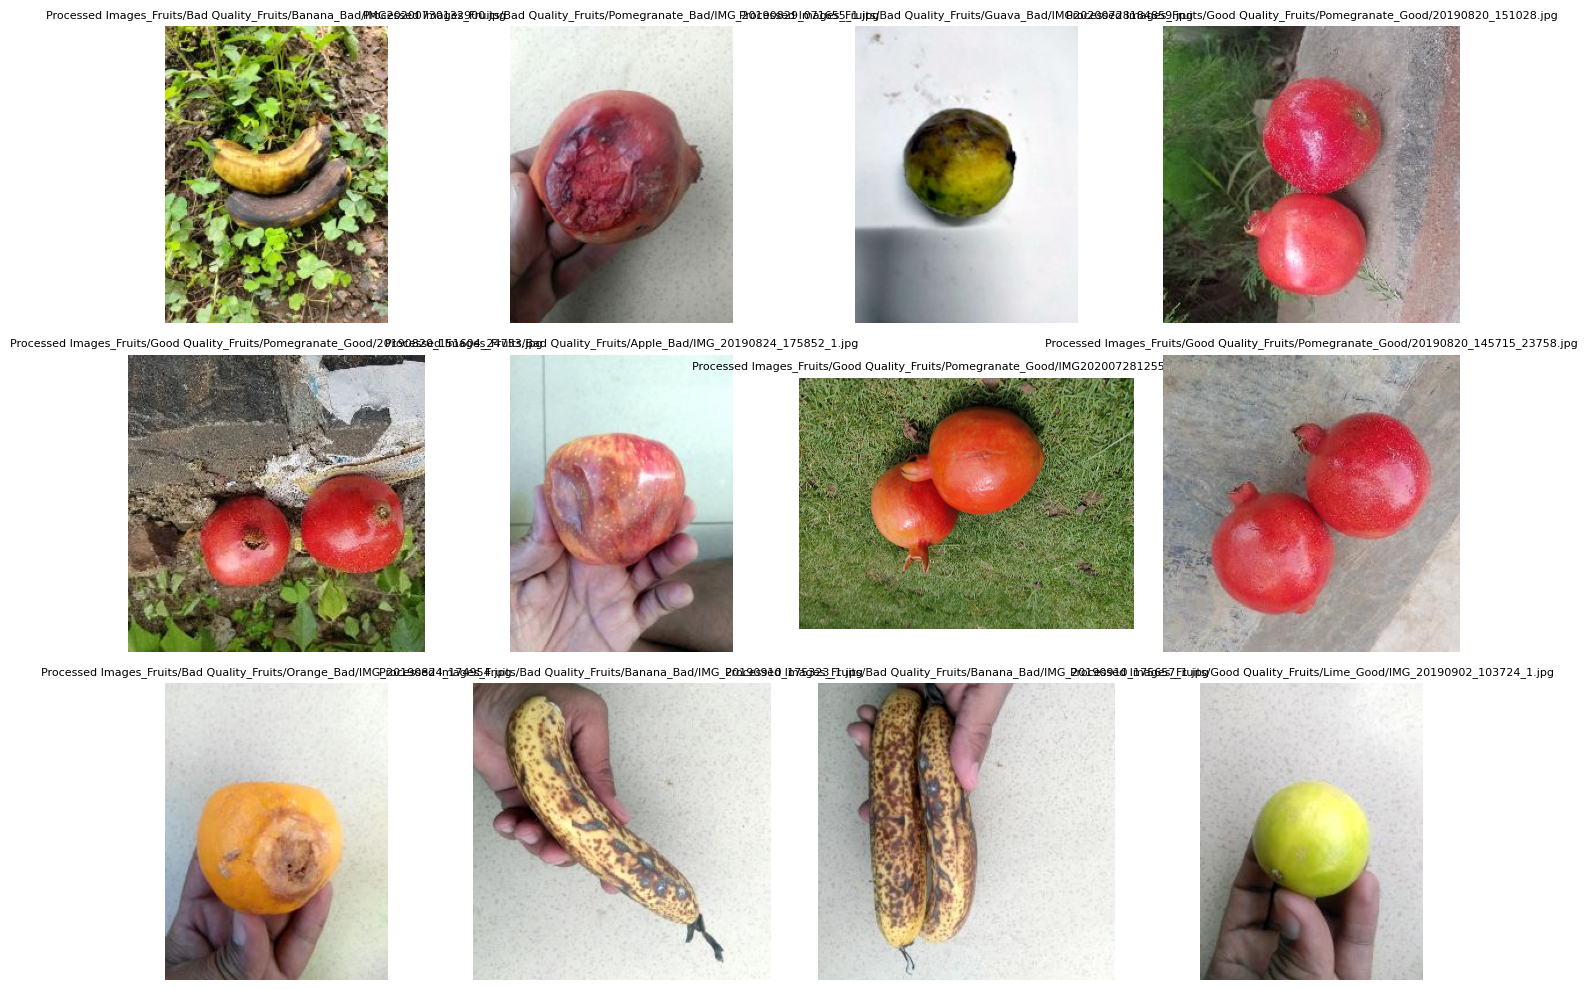

In [9]:
sample_images = random.sample(original_images, min(12, len(original_images)))

plt.figure(figsize=(14, 10))
for i, image_path in enumerate(sample_images):
    image = Image.open(image_path).convert("RGB")
    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    relative_path = image_path.relative_to(EXTRACT_DIR)
    plt.title(str(relative_path), fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()


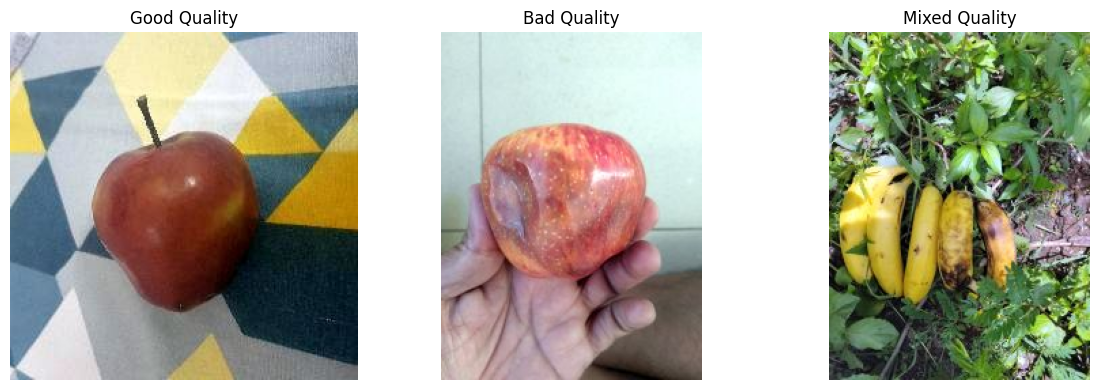

In [10]:
quality_samples = {}

for image_path in original_images:
    path_text = str(image_path).lower()
    if "good" in path_text:
        quality = "Good"
    elif "bad" in path_text:
        quality = "Bad"
    elif "mixed" in path_text:
        quality = "Mixed"
    else:
        continue

    if quality not in quality_samples:
        quality_samples[quality] = image_path

plt.figure(figsize=(12, 4))
for i, quality in enumerate(["Good", "Bad", "Mixed"]):
    image_path = quality_samples.get(quality)
    if image_path:
        image = Image.open(image_path).convert("RGB")
        plt.subplot(1, 3, i + 1)
        plt.imshow(image)
        plt.title(f"{quality} Quality")
        plt.axis("off")
plt.tight_layout()
plt.show()


In [11]:
FRUITS = ["apple", "banana", "guava", "lime", "orange", "pomegranate"]
QUALITIES = ["Good", "Bad", "Mixed"]

print("Fruits:", FRUITS)
print("Qualities:", QUALITIES)
print("Expected classes:", len(FRUITS) * len(QUALITIES))


Fruits: ['apple', 'banana', 'guava', 'lime', 'orange', 'pomegranate']
Qualities: ['Good', 'Bad', 'Mixed']
Expected classes: 18


In [12]:
def get_quality(folder_name):
    name = folder_name.lower()
    if "good" in name:
        return "Good"
    elif "bad" in name:
        return "Bad"
    elif "mixed" in name:
        return "Mixed"
    return None

def get_fruit(folder_name):
    name = folder_name.lower()
    for fruit in FRUITS:
        if fruit in name:
            return fruit
    return None

copied_images = 0

for quality_folder in Path(EXTRACT_DIR).rglob("*"):
    if not quality_folder.is_dir():
        continue

    quality = get_quality(quality_folder.name)
    if quality is None:
        continue

    for fruit_folder in quality_folder.iterdir():
        if not fruit_folder.is_dir():
            continue

        fruit = get_fruit(fruit_folder.name)
        if fruit is None:
            continue

        class_name = f"{fruit}_{quality}"
        target_folder = Path(ORGANIZED_DIR) / class_name
        target_folder.mkdir(parents=True, exist_ok=True)

        for image_file in fruit_folder.iterdir():
            if image_file.is_file() and image_file.suffix.lower() in IMAGE_EXTENSIONS:
                destination = target_folder / image_file.name
                if destination.exists():
                    destination = target_folder / f"{copied_images}_{image_file.name}"
                shutil.copy2(image_file, destination)
                copied_images += 1

print("Images copied:", copied_images)


Images copied: 19248


In [13]:
classes = sorted([
    folder.name
    for folder in Path(ORGANIZED_DIR).iterdir()
    if folder.is_dir()
])

print("Number of classes:", len(classes))
for i, class_name in enumerate(classes):
    print(i, "→", class_name)


Number of classes: 17
0 → apple_Bad
1 → apple_Good
2 → apple_Mixed
3 → banana_Bad
4 → banana_Good
5 → banana_Mixed
6 → guava_Bad
7 → guava_Good
8 → guava_Mixed
9 → lime_Bad
10 → lime_Good
11 → orange_Bad
12 → orange_Good
13 → orange_Mixed
14 → pomegranate_Bad
15 → pomegranate_Good
16 → pomegranate_Mixed


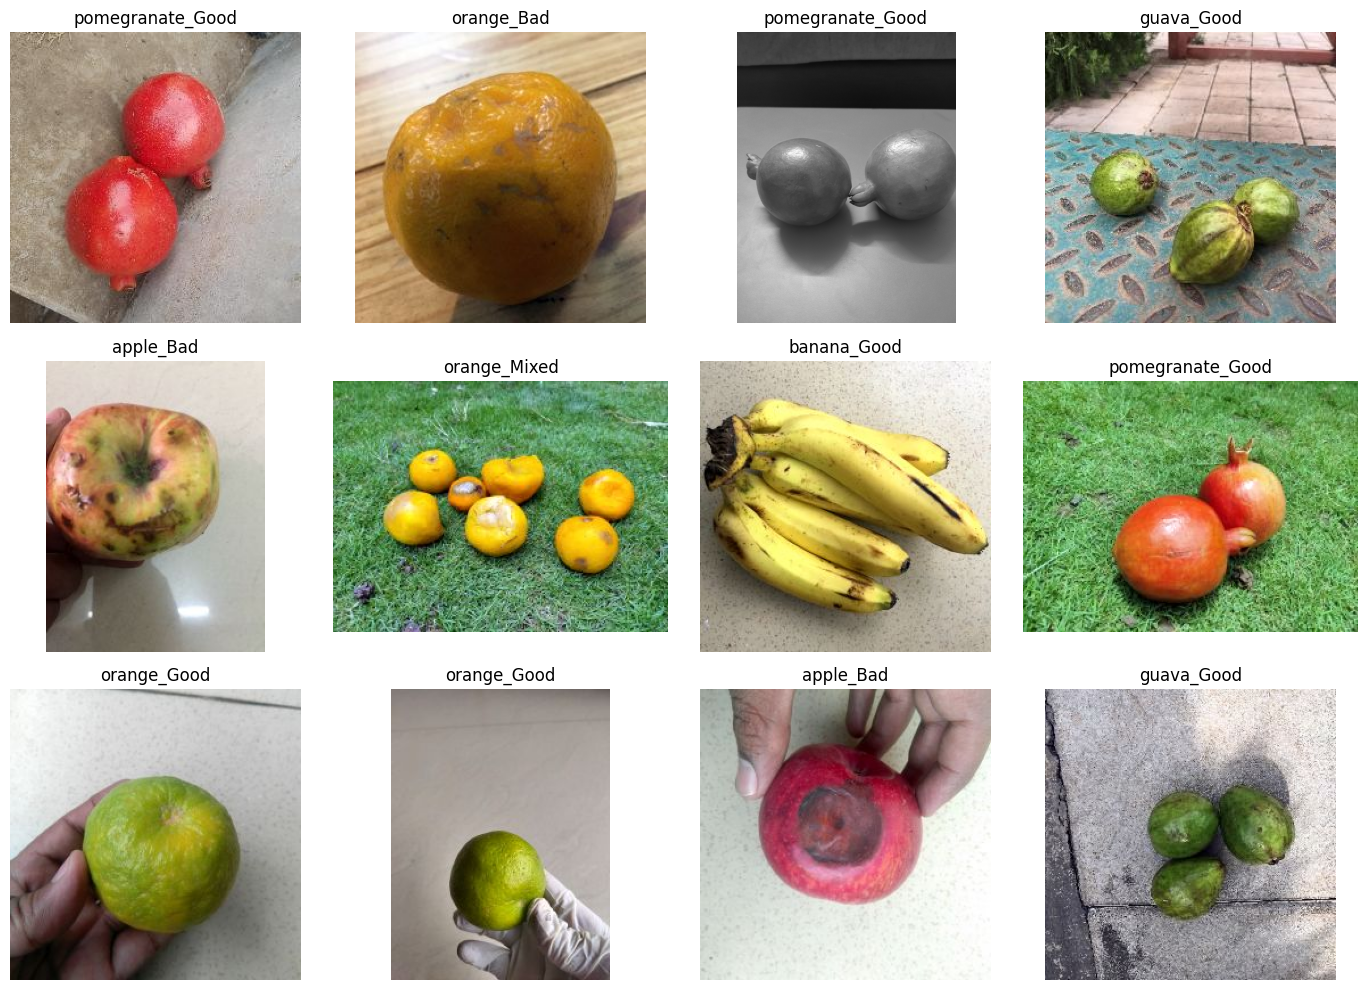

In [14]:
organized_images = []

for image_path in Path(ORGANIZED_DIR).rglob("*"):
    if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
        organized_images.append(image_path)

sample_images = random.sample(organized_images, min(12, len(organized_images)))

plt.figure(figsize=(14, 10))
for i, image_path in enumerate(sample_images):
    image = Image.open(image_path).convert("RGB")
    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(image_path.parent.name)
    plt.axis("off")
plt.tight_layout()
plt.show()


In [15]:
data = []

for class_name in classes:
    class_path = Path(ORGANIZED_DIR) / class_name
    for image_file in class_path.iterdir():
        if image_file.is_file() and image_file.suffix.lower() in IMAGE_EXTENSIONS:
            data.append({"filepath": str(image_file), "class": class_name})

df = pd.DataFrame(data)

print("Total images:", len(df))
print("Total classes:", df["class"].nunique())
df.head()


Total images: 19248
Total classes: 17


,filepath,class
0,/content/drive/MyDrive/Fruits10/organized/appl...,apple_Bad
1,/content/drive/MyDrive/Fruits10/organized/appl...,apple_Bad
2,/content/drive/MyDrive/Fruits10/organized/appl...,apple_Bad
3,/content/drive/MyDrive/Fruits10/organized/appl...,apple_Bad
4,/content/drive/MyDrive/Fruits10/organized/appl...,apple_Bad


In [16]:
class_to_index = {class_name: index for index, class_name in enumerate(classes)}
index_to_class = {str(index): class_name for class_name, index in class_to_index.items()}

df["label"] = df["class"].map(class_to_index)

print(class_to_index)


{'apple_Bad': 0, 'apple_Good': 1, 'apple_Mixed': 2, 'banana_Bad': 3, 'banana_Good': 4, 'banana_Mixed': 5, 'guava_Bad': 6, 'guava_Good': 7, 'guava_Mixed': 8, 'lime_Bad': 9, 'lime_Good': 10, 'orange_Bad': 11, 'orange_Good': 12, 'orange_Mixed': 13, 'pomegranate_Bad': 14, 'pomegranate_Good': 15, 'pomegranate_Mixed': 16}


In [17]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.25 / 0.30, # 25% test out of the remaining 30%, which means 5% for validation
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 13473
Validation: 962
Test: 4813


In [18]:
train_df.to_csv(f"{SPLIT_DIR}/train.csv", index=False)
val_df.to_csv(f"{SPLIT_DIR}/validation.csv", index=False)
test_df.to_csv(f"{SPLIT_DIR}/test.csv", index=False)

print("Split CSV files saved.")


Split CSV files saved.


In [19]:
print("TRAIN")
print(train_df["class"].value_counts().sort_index())

print("\nVALIDATION")
print(val_df["class"].value_counts().sort_index())

print("\nTEST")
print(test_df["class"].value_counts().sort_index())


TRAIN
class
apple_Bad             799
apple_Good            804
apple_Mixed            79
banana_Bad            761
banana_Good           779
banana_Mixed          199
guava_Bad             790
guava_Good            806
guava_Mixed           104
lime_Bad              759
lime_Good             766
orange_Bad            811
orange_Good           851
orange_Mixed           88
pomegranate_Bad       831
pomegranate_Good     4158
pomegranate_Mixed      88
Name: count, dtype: int64

VALIDATION
class
apple_Bad             57
apple_Good            57
apple_Mixed            6
banana_Bad            54
banana_Good           56
banana_Mixed          14
guava_Bad             57
guava_Good            58
guava_Mixed            7
lime_Bad              54
lime_Good             55
orange_Bad            58
orange_Good           61
orange_Mixed           6
pomegranate_Bad       59
pomegranate_Good     297
pomegranate_Mixed      6
Name: count, dtype: int64

TEST
class
apple_Bad             285
apple_Good   

In [20]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label


[✓] Output logged successfully.


In [21]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomContrast(0.10)
])


[✓] Output logged successfully.


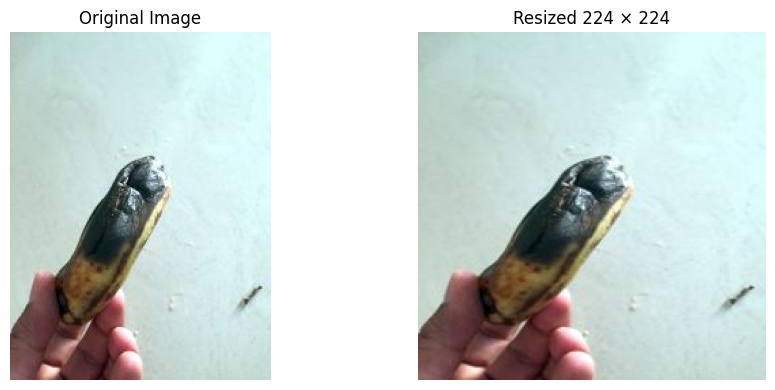

In [22]:
sample_path = train_df.iloc[0]["filepath"]

image = Image.open(sample_path).convert("RGB")
original_image = np.array(image)
resized_image = np.array(image.resize(IMG_SIZE))

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(original_image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(resized_image)
plt.title("Resized 224 × 224")
plt.axis("off")

plt.tight_layout()
plt.show()


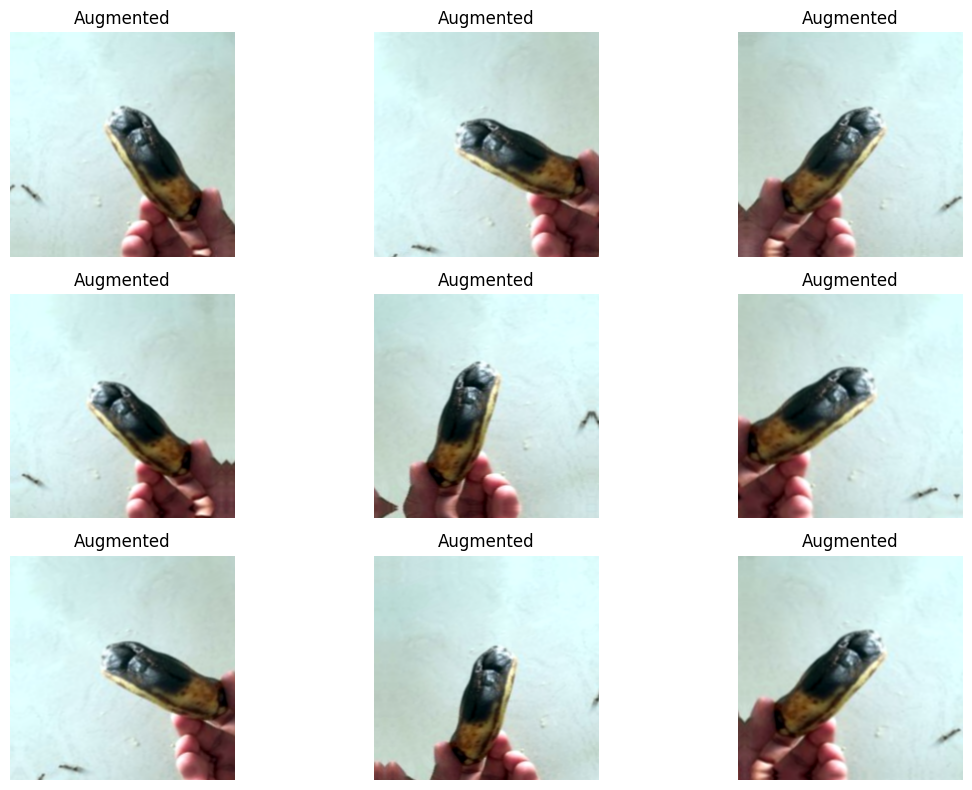

In [23]:
sample_tensor = tf.convert_to_tensor(resized_image, dtype=tf.float32)
sample_tensor = tf.expand_dims(sample_tensor, axis=0)

plt.figure(figsize=(12, 8))

for i in range(9):
    augmented = data_augmentation(sample_tensor, training=True)
    augmented = tf.cast(augmented[0], tf.uint8)

    plt.subplot(3, 3, i + 1)
    plt.imshow(augmented)
    plt.title("Augmented")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [24]:
metadata = {
    "classes": classes,
    "class_to_index": class_to_index,
    "index_to_class": index_to_class,
    "num_classes": len(classes),
    "image_size": [224, 224],
    "batch_size": 32,
    "train_split": 0.70,
    "validation_split": 0.05,
    "test_split": 0.25
}

METADATA_PATH = f"{METADATA_DIR}/metadata.json"

with open(METADATA_PATH, "w") as f:
    json.dump(metadata, f, indent=4)

print("Metadata saved:", METADATA_PATH)

Metadata saved: /content/drive/MyDrive/Fruits10/metadata/metadata.json


In [25]:
print("========== PREPROCESSING COMPLETE ==========")
print("Total images:", len(df))
print("Classes:", len(classes))
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))
print("Organized data:", ORGANIZED_DIR)
print("Split files:", SPLIT_DIR)
print("Metadata:", METADATA_PATH)

========== PREPROCESSING COMPLETE ==========
Total images: 19248
Classes: 17
Train: 13473
Validation: 962
Test: 4813
Organized data: /content/drive/MyDrive/Fruits10/organized
Split files: /content/drive/MyDrive/Fruits10/splits
Metadata: /content/drive/MyDrive/Fruits10/metadata/metadata.json


In [26]:
def create_tf_dataset(df, shuffle=False, augment=False):
    filepaths = df["filepath"].values
    labels = df["label"].values

    dataset = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    dataset = dataset.map(load_image, num_parallel_calls=AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=BATCH_SIZE * 4)

    if augment:
        dataset = dataset.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)
    return dataset

train_dataset = create_tf_dataset(train_df, shuffle=True, augment=True)
val_dataset = create_tf_dataset(val_df)
test_dataset = create_tf_dataset(test_df)

print("Train Dataset elements:", tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation Dataset elements:", tf.data.experimental.cardinality(val_dataset).numpy())
print("Test Dataset elements:", tf.data.experimental.cardinality(test_dataset).numpy())

Train Dataset elements: 422
Validation Dataset elements: 31
Test Dataset elements: 151


### Compile the Model

In [27]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Model compiled successfully.")

[✓] Output logged successfully.


Let's check the contents of the `SPLIT_DIR` and `METADATA_DIR` to confirm the files were saved.

Traning


In [28]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from google.colab import drive

[✓] Output logged successfully.


### Create `tf.data.Dataset` objects

In [29]:
# ============================================================
# LOAD EVERYTHING FROM LOCAL COLAB STORAGE
# ============================================================

BASE_DIR = "/content/Fruits10"
SPLIT_DIR = f"{BASE_DIR}/splits"
METADATA_DIR = f"{BASE_DIR}/metadata"
MODEL_DIR = f"{BASE_DIR}/models"

os.makedirs(MODEL_DIR, exist_ok=True)

train_df = pd.read_csv(f"{SPLIT_DIR}/train.csv")
val_df = pd.read_csv(f"{SPLIT_DIR}/validation.csv")
test_df = pd.read_csv(f"{SPLIT_DIR}/test.csv")

with open(f"{METADATA_DIR}/metadata.json", "r") as f:
    metadata = json.load(f)

classes = metadata["classes"]
class_to_index = metadata["class_to_index"]
index_to_class = metadata["index_to_class"]

IMG_SIZE = tuple(metadata["image_size"])
NUM_CLASSES = metadata["num_classes"]

print("Everything loaded from local Colab storage")
print("Base directory:", BASE_DIR)
print("Classes:", NUM_CLASSES)
print(classes)


Classes: 17
['apple_Bad', 'apple_Good', 'apple_Mixed', 'banana_Bad', 'banana_Good', 'banana_Mixed', 'guava_Bad', 'guava_Good', 'guava_Mixed', 'lime_Bad', 'lime_Good', 'orange_Bad', 'orange_Good', 'orange_Mixed', 'pomegranate_Bad', 'pomegranate_Good', 'pomegranate_Mixed']


In [30]:
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label


[✓] Output logged successfully.


In [31]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomContrast(0.10)
])


[✓] Output logged successfully.


In [32]:
def create_dataset(dataframe, training=False):
    paths = dataframe["filepath"].values
    labels = dataframe["label"].values

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        dataset = dataset.shuffle(
            min(len(dataframe), 10000),
            seed=42
        )

    # Parallel local image loading
    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    # Cache decoded/resized images in Colab runtime memory.
    # Augmentation is applied after cache so it changes every epoch.
    dataset = dataset.cache()

    if training:
        dataset = dataset.map(
            lambda x, y: (data_augmentation(x, training=True), y),
            num_parallel_calls=AUTOTUNE
        )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


train_ds = create_dataset(train_df, training=True)
val_ds = create_dataset(val_df, training=False)
test_ds = create_dataset(test_df, training=False)

print("Datasets ready.")


Datasets ready.


In [33]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.30)(x)
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.20)(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 17)             │         4,369 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,381,876 (16.72 MB)

 Trainable params: 332,305 (1.27 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

[✓] Output logged successfully.
